In [22]:
import os
import sys
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("code"))

from protein_from_RNA import *
from reconstruct_RNA_history import *

Some refs for getting reverse time Markov generator:

https://arxiv.org/abs/2502.19183 (p. 3)

https://www.randomservices.org/random/markov/TimeReversal2.html
 
https://link.springer.com/book/10.1007/978-1-4612-3038-0 (p. 239)

In [23]:
# ==== Transcription rate ====
alpha_mu = 2 # (Corresponds to ~7 mRNAs/hour, per Chronocell paper)
alpha_sd = 1

# === Splicing rate ===
beta_mu = 2 # np.log(splicing_rate) # (Corresponds to ~8.5 minute splicing rate, per Chronocell paper)
beta_sd = 0.5

# === mRNA degradation rate ===
gamma_mu = 0.5 # (Corresponds to ~2.8 hour half-life, per Chronocell paper)
gamma_sd = 0.5

n = 100 # No. cells per lineage
p = 1 # No. genes
topo = np.array([[0, 1, 2, 3]])
tau = (0, 2, 6, 8)

U_max = 10 
S_max = 25

In [24]:
# Simulate data

random_seed = 666 
# np.random.seed(random_seed)

theta = get_RNA_params(topo, p, alpha_mu, alpha_sd, beta_mu, beta_sd, gamma_mu, gamma_sd, random_seed=random_seed)
Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)


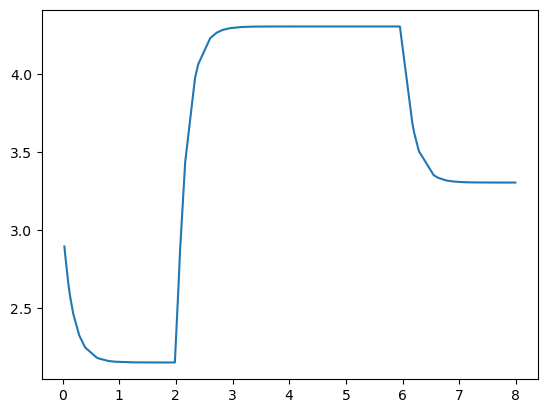

In [25]:
plt.plot(true_t, Y[:, :, 0])

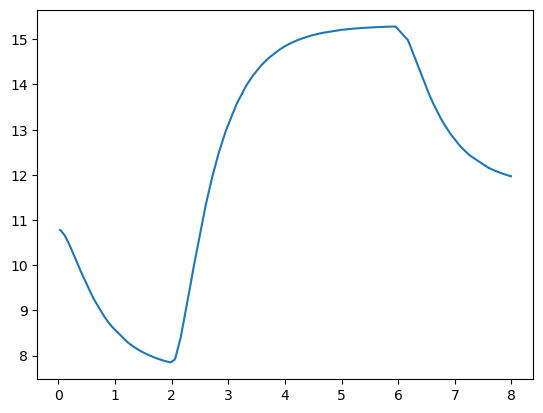

In [26]:
plt.plot(true_t, Y[:, :, 1])

In [27]:
t = true_t
theta_ = theta[0].copy()
a0 = theta_[0] # Starting RNA abundance 
a = theta_[1:len(topo.flatten())] 
beta = theta_[-2] # Splicing rate
alpha = a * beta # These values are divided by splicing rate; removing this factor now
gamma = theta_[-1] # Degradation rate
state_grid = np.searchsorted(tau, t, side="right") - 1 # Right closed convention τ_j < t_i ≤ τ_{j+1} (per Chronocell model)

states, index_for = enumerate_states(U_max, S_max)

In [28]:
# Prep forward rate matrices

A = []
for i in range(0, len(alpha)):
    rxns = define_reactions(alpha[i], beta, gamma)
    A1 = create_transition_matrix(rxns, U_max, S_max)
    A.append(A1)

# Reverse generator

In [29]:
# Initialize X_fwd with stationary distribution (steady state at t=0)

alpha0 = a0 * beta
rxns0 = define_reactions(alpha0, beta, gamma) # define_reactions(alpha0, beta, gamma)
A0 = create_transition_matrix(rxns0, U_max, S_max)
pi = stationary_from_transition_matrix(A0)

In [30]:
states[np.argmax(pi)]

(3, 10)

In [31]:
u_curr = np.round(Y[0, :, 0])[0]
s_curr = np.round(Y[0, :, 1])[0]
u_curr, s_curr

(np.float64(3.0), np.float64(11.0))

In [32]:
# Get forward distribution (needed to calculate backward distribution)
X_fwd = forward_distribution(A, pi, states, t, tau, state_grid)

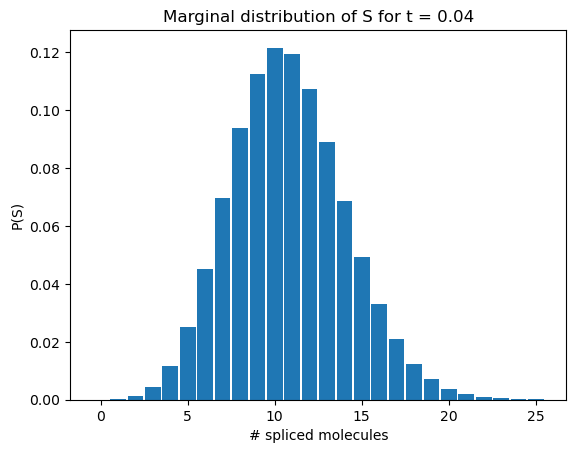

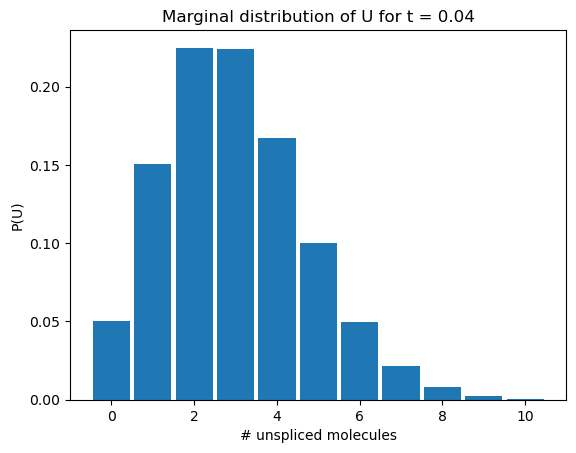

In [33]:
# Visualize marginals for U and S

X_fwd_U, X_fwd_S = marginal_distribution(X_fwd, U_max, S_max, t, states)

k=1

plt.figure()
plt.bar(np.arange(0, S_max + 1) , X_fwd_S[:, k], width=0.9, align='center')
plt.xlabel("# spliced molecules")
plt.ylabel("P(S)")
plt.title(f"Marginal distribution of S for t = {np.round(t[k], 2)}")
plt.show()

plt.figure()
plt.bar(np.arange(0, U_max + 1) , X_fwd_U[:, k], width=0.9, align='center')
plt.xlabel("# unspliced molecules")
plt.ylabel("P(U)")
plt.title(f"Marginal distribution of U for t = {np.round(t[k], 2)}")
plt.show()

In [34]:
# Start with observed counts:
u_curr = np.round(Y[-1, :, 0])[0]
s_curr = np.round(Y[-1, :, 1])[0]
x_curr = np.zeros(shape=(A[0].shape[0],), dtype="float")
x_curr[index_for[(u_curr, s_curr)]] = 1.0

print("Start backward process with (# unspliced, spliced):", u_curr, s_curr)
print("Simulated (# unspliced, spliced):", np.round(Y[-1, :, 0], 3), np.round(Y[-1, :, 1], 3))
print("-------")

X_bw_init = np.zeros(shape=(len(states), len(t))) 
X_bw_init[:, -1] = x_curr

X_bw = backward_distribution(Y, A, X_bw_init, X_fwd, states, t, tau, state_grid)

Start backward process with (# unspliced, spliced): 3.0 12.0
Simulated (# unspliced, spliced): [3.303] [11.97]
-------
Jump backwards from t = 7.99 to t = 7.936 :
Highest probability state (# unspliced, spliced): (3, 12)
Simulated (# unspliced, spliced): [3.3] [11.99]
Sum X(t_k) = 1.0
-------
Jump backwards from t = 7.936 to t = 7.827 :
Highest probability state (# unspliced, spliced): (3, 12)
Simulated (# unspliced, spliced): [3.3] [12.03]
Sum X(t_k) = 0.9999999999999996
-------
Jump backwards from t = 7.827 to t = 7.754 :
Highest probability state (# unspliced, spliced): (3, 12)
Simulated (# unspliced, spliced): [3.3] [12.07]
Sum X(t_k) = 0.9999999999999989
-------
Jump backwards from t = 7.754 to t = 7.701 :
Highest probability state (# unspliced, spliced): (3, 12)
Simulated (# unspliced, spliced): [3.3] [12.1]
Sum X(t_k) = 0.9999999999999983
-------
Jump backwards from t = 7.701 to t = 7.676 :
Highest probability state (# unspliced, spliced): (3, 12)
Simulated (# unspliced, spliced

In [35]:
X_bw_U, X_bw_S = marginal_distribution(X_bw, U_max, S_max, t, states)


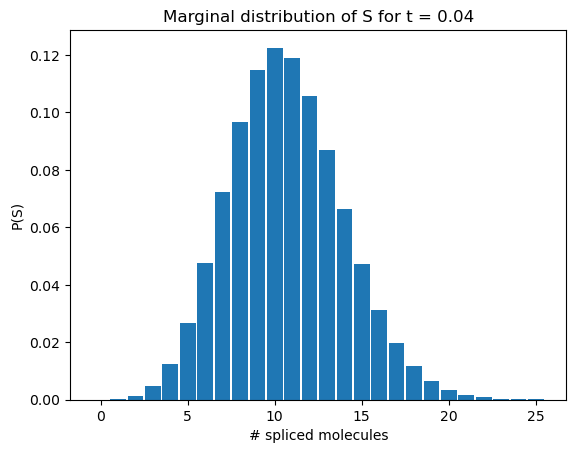

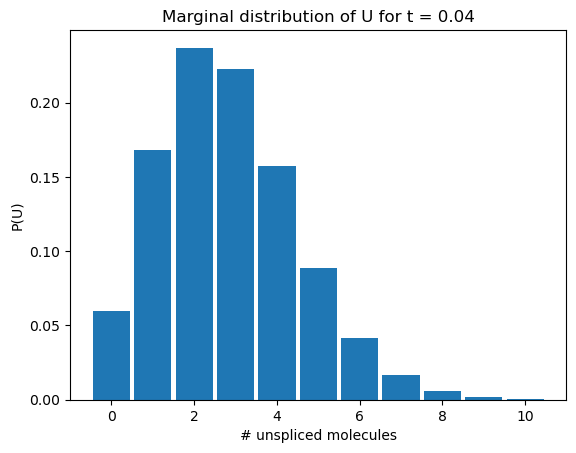

In [36]:
k=1

plt.figure()
plt.bar(np.arange(0, S_max + 1) , X_bw_S[:, k], width=0.9, align='center')
plt.xlabel("# spliced molecules")
plt.ylabel("P(S)")
plt.title(f"Marginal distribution of S for t = {np.round(t[k], 2)}")
plt.show()

plt.figure()
plt.bar(np.arange(0, U_max + 1) , X_bw_U[:, k], width=0.9, align='center')
plt.xlabel("# unspliced molecules")
plt.ylabel("P(U)")
plt.title(f"Marginal distribution of U for t = {np.round(t[k], 2)}")
plt.show()

# Taking inverse to go backwards

In [ ]:
# For each time step, calculate previous state using current state

# Start with observed counts:
u_curr = np.round(Y[-1, :, 0])[0]
s_curr = np.round(Y[-1, :, 1])[0]
x_curr = np.zeros(shape=(A[0].shape[0],), dtype="float")
x_curr[index_for[(u_curr, s_curr)]] = 1.0

print("Start backward process with (# unspliced, spliced):", u_curr, s_curr)
print("Simulated (# unspliced, spliced):", np.round(Y[-1, :, 0], 3), np.round(Y[-1, :, 1], 3))
print("-------")

for k in reversed(range(1, len(t))):
    t_prev, t_curr = t[k-1], t[k]
    # print("t_prev, t_curr:", t_prev, t_curr)
    state_prev, state_curr = state_grid[k-1], state_grid[k]
    # print("state_prev, state_curr:", state_prev, state_curr)

    if state_prev == state_curr:
        dt = t_curr - t_prev
        A_k = A[state_curr]
        x_prev = x_curr @ np.linalg.inv(sp.linalg.expm(A_k * dt)) 
        
    else:
        # State switch happens in current interval
        tau_c = tau[state_curr]
        
        print("State switch at k =", k)
        # print("tau_c:", tau_c)
        # print("t_curr:", t_curr)
        # print("t_prev:", t_prev)
        
        # Split backward march into 2 steps
        # interval 2: (state_switch_time, t_k]
        dt2 = t_curr - tau_c
        A_k2 = A[state_curr]
        x_mid = x_curr @ np.linalg.inv(sp.linalg.expm(A_k2 * dt2)) 
        
        # interval 1: (t_k-1, state_switch_time]
        dt1 = tau_c - t_prev

        A_k1 = A[state_prev]
        x_prev = x_mid @ np.linalg.inv(sp.linalg.expm(A_k1 * dt1)) 
    
    x_curr = x_prev
    
    print("Jump backwards from t =", np.round(t_curr, 3), "to t =", np.round(t_prev, 3), ":")
    print("Highest probability state (# unspliced, spliced):", states[np.argmax(x_curr)])
    idx = np.searchsorted(t, t_prev)
    print("Simulated (# unspliced, spliced):", np.round(Y[idx, :, 0], 2), np.round(Y[idx, :, 1], 2))
    print("Sum X(t_k) =", np.sum(x_curr))
    print("-------")
    

Start backward process with (# unspliced, spliced): 3.0 12.0
Simulated (# unspliced, spliced): [3.303] [11.97]
-------
Jump backwards from t = 7.99 to t = 7.936 :
Highest probability state (# unspliced, spliced): (4, 11)
Simulated (# unspliced, spliced): [3.3] [11.99]
Sum X(t_k) = 0.9999999999998757
-------
Jump backwards from t = 7.936 to t = 7.827 :
Highest probability state (# unspliced, spliced): (6, 14)
Simulated (# unspliced, spliced): [3.3] [12.03]
Sum X(t_k) = 0.9999998559651431
-------
Jump backwards from t = 7.827 to t = 7.754 :
Highest probability state (# unspliced, spliced): (7, 15)
Simulated (# unspliced, spliced): [3.3] [12.07]
Sum X(t_k) = 1.000014528632164
-------
Jump backwards from t = 7.754 to t = 7.701 :
Highest probability state (# unspliced, spliced): (7, 17)
Simulated (# unspliced, spliced): [3.3] [12.1]
Sum X(t_k) = 0.9970817565917969
-------
Jump backwards from t = 7.701 to t = 7.676 :
Highest probability state (# unspliced, spliced): (7, 18)
Simulated (# unsp

/tmp/ipykernel_562543/477771673.py:23: RuntimeWarning: overflow encountered in matmul
  x_prev = x_curr @ eA_k_inv
/tmp/ipykernel_562543/477771673.py:23: RuntimeWarning: invalid value encountered in matmul
  x_prev = x_curr @ eA_k_inv


Jump backwards from t = 2.72 to t = 2.606 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [4.23] [11.35]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.606 to t = 2.394 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [4.06] [9.99]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.394 to t = 2.346 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [3.99] [9.65]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.346 to t = 2.336 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [3.97] [9.58]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.336 to t = 2.163 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [3.43] [8.41]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.163 to t = 2.073 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced,

In [ ]:
# Start with observed counts:
u_curr = np.round(Y[0, :, 0])[0]
s_curr = np.round(Y[0, :, 1])[0]
x_curr = np.zeros(shape=(A[0].shape[0],), dtype="float")
x_curr[index_for[(u_curr, s_curr)]] = 1.0

print("Start forward process with (# unspliced, spliced):", u_curr, s_curr)
print("Simulated (# unspliced, spliced):", np.round(Y[0, :, 0], 3), np.round(Y[0, :, 1], 3))
print("-------")

for k in range(0, len(t)-1): 
    t_curr, t_next = t[k], t[k + 1]
    state_curr, state_next = state_grid[k], state_grid[k+1]
    # x_curr = X_fwd[:, k]
    
    if state_curr == state_next:
        dt = t_next - t_curr
        A_k = A[state_curr]
        x_next = x_curr @ sp.linalg.expm(A_k * dt) 
        
    else:   
        # State switch happens in current interval
        t_s = tau[state_next]

        # Split backward march into 2 steps
        dt1 = t_s - t_curr # left interval: [t_k, state_switch_time)
        A_k1 = A[state_curr]
        x_mid = x_curr @ sp.linalg.expm(A_k1 * dt1)

        dt2 = t_next - t_s # right interval: [state_switch_time, t_{k+1})
        A_k2 = A[state_next]
        x_next = x_mid @ sp.linalg.expm(A_k2 * dt2) 
    
    x_curr = x_next
    
    print("Jump fowards from t =", np.round(t_curr, 3), "to t =", np.round(t_next, 3), ":")
    print("Highest probability state (# unspliced, spliced):", states[np.argmax(x_curr)])
    idx = np.searchsorted(t, t_next)
    print("Simulated (# unspliced, spliced):", np.round(Y[idx, :, 0], 2), np.round(Y[idx, :, 1], 2))
    print("Sum X(t_k) =", np.sum(x_curr))
    print("-------")
    
    # X_fwd[:, k+1] = x_next

Start forward process with (# unspliced, spliced): 3.0 11.0
Simulated (# unspliced, spliced): [2.894] [10.781]
-------
Jump fowards from t = 0.031 to t = 0.041 :
Highest probability state (# unspliced, spliced): (3, 11)
Simulated (# unspliced, spliced): [2.86] [10.77]
Sum X(t_k) = 0.9999999999999999
-------
Jump fowards from t = 0.041 to t = 0.102 :
Highest probability state (# unspliced, spliced): (3, 11)
Simulated (# unspliced, spliced): [2.65] [10.68]
Sum X(t_k) = 0.9999999999999997
-------
Jump fowards from t = 0.102 to t = 0.13 :
Highest probability state (# unspliced, spliced): (2, 11)
Simulated (# unspliced, spliced): [2.58] [10.62]
Sum X(t_k) = 0.9999999999999998
-------
Jump fowards from t = 0.13 to t = 0.132 :
Highest probability state (# unspliced, spliced): (2, 11)
Simulated (# unspliced, spliced): [2.58] [10.62]
Sum X(t_k) = 0.9999999999999996
-------
Jump fowards from t = 0.132 to t = 0.186 :
Highest probability state (# unspliced, spliced): (2, 11)
Simulated (# unspliced